# Лабораторная работа №1
## Вариант 1
**Студент:** Гайфуллина Рената, ПМИ 3-1

## Оценка качества моделирования B-сплайнами: MSE и переобучение

# 1. Постановка задачи
# Задача 1
На данных варианта повторить расчёты и построить графики. Пояснить выбор наилучшего количества степеней свободы.
# Задача 2
Повторить расчёты, меняя характеристики согласно варианту. Проанализировать, как меняется MSE при изменении характеристик.

Будем считать, что существует один числовой признак \(X\) и непрерывная целевая переменная \(Y\).

Данные генерируются по формуле

$$
Y = f(X) + \varepsilon,
$$

где

$$
\varepsilon \sim N(0, \sigma^2).
$$

То есть наблюдаемое значение $Y$ состоит из:

1. закономерности $f(X)$;
2. случайного шума $\varepsilon$.

Возьмём гладкую нелинейную функцию:

$$
f(X)=13+3.5\sin\left(\frac{X-30}{9}\right).
$$


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer

In [2]:
RANDOM_STATE = 1

N_ALL = 600          # общее число наблюдений
TRAIN_PERCENT = 0.70
X_MIN = 5
X_MAX = 105
SIGMA = 1.0         # стандартное отклонение шума

SPLINE_DEGREE = 3   # кубический сплайн
MIN_KNOTS = 2
MAX_KNOTS = 25

In [3]:
def true_function(x):

    return 13 + 3.5 * np.sin((x - 30) / 9)



rng = np.random.default_rng(RANDOM_STATE)

x = rng.uniform(X_MIN, X_MAX, N_ALL)
noise = rng.normal(loc=0, scale=SIGMA, size=N_ALL)

y = true_function(x) + noise


X = x.reshape(-1, 1)

# Делим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=TRAIN_PERCENT,
    random_state=RANDOM_STATE
)

print(f"Всего наблюдений: {len(X)}")
print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")

Всего наблюдений: 600
Обучающая выборка: 420
Тестовая выборка: 180



На **обучающей выборке** модель подбирает свои параметры.

На **тестовой выборке** мы проверяем, насколько хорошо обученная модель работает на данных, которые она не использовала при обучении.

Если модель показывает очень маленькую ошибку на train, но большую ошибку на test, это один из признаков **переобучения**.

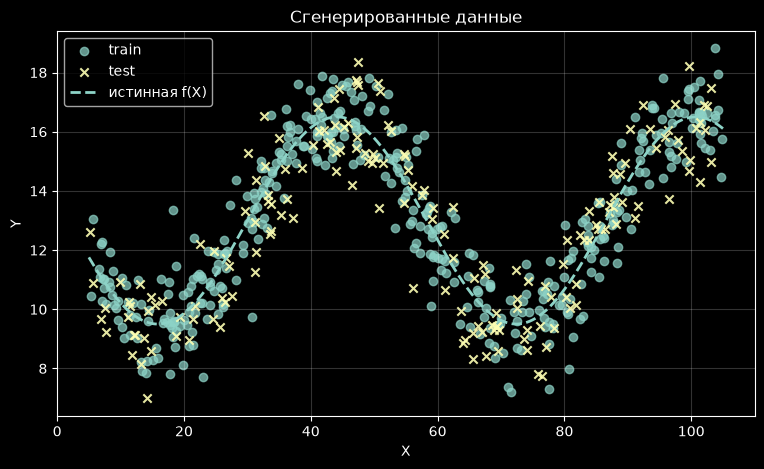

In [4]:
# Посмотрим на исходные данные

x_grid = np.linspace(X_MIN, X_MAX, 500)
y_grid_true = true_function(x_grid)

plt.figure(figsize=(9, 5))

plt.scatter(X_train[:, 0], y_train, marker="o", alpha=0.7, label="train")
plt.scatter(X_test[:, 0], y_test, marker="x", alpha=0.9, label="test")
plt.plot(x_grid, y_grid_true, linestyle="--", linewidth=2, label="истинная f(X)")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Сгенерированные данные")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# 2. Среднеквадратическая ошибка MSE

Для регрессии будем использовать среднеквадратическую ошибку:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2.
$$

Где:

- $y_i$ — фактическое значение;
- $\hat y_i$ — прогноз модели;
- $n$ — число наблюдений.

Чем меньше MSE, тем в среднем прогноз модели ближе к фактическим значениям.

In [5]:
# Реализуем MSE самостоятельно

def mse_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# Простейший пример:
y_example = np.array([2, 4, 6])
y_pred_example = np.array([3, 5, 5])

mse_example = mse_manual(y_example, y_pred_example)

print("MSE =", mse_example)

MSE = 1.0


Сплайн — это гладкая функция, которая составлена из нескольких полиномиальных участков.

B-сплайн удобно представить так:

1. диапазон \(X\) разбивается узлами;
2. вокруг узлов строятся базисные функции;
3. линейная регрессия подбирает коэффициенты при этих функциях.

Чем больше узлов, тем больше локальных изгибов может воспроизвести итоговая модель.

Посмотрим, как выглядят B-сплайновые базисные функции.

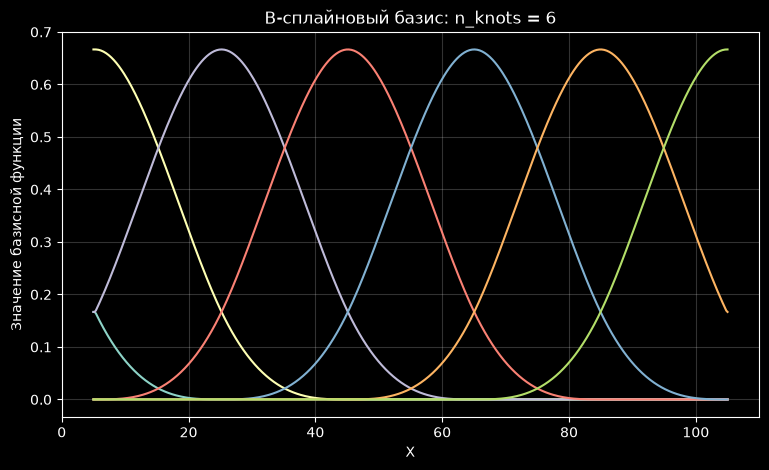

Число получившихся признаков после SplineTransformer: 7


In [6]:
# Визуализируем базисные функции B-сплайна

demo_knots = 6

basis_transformer = SplineTransformer(
    n_knots=demo_knots,
    degree=SPLINE_DEGREE,
    include_bias=False,
    knots="uniform"
)

basis_transformer.fit(X_train)

X_grid_for_basis = x_grid.reshape(-1, 1)
basis_values = basis_transformer.transform(X_grid_for_basis)

plt.figure(figsize=(9, 5))

for j in range(basis_values.shape[1]):
    plt.plot(x_grid, basis_values[:, j], linewidth=1.5)

plt.xlabel("X")
plt.ylabel("Значение базисной функции")
plt.title(f"B-сплайновый базис: n_knots = {demo_knots}")
plt.grid(alpha=0.2)
plt.show()

print("Число получившихся признаков после SplineTransformer:",
      basis_values.shape[1])

Сначала возьмём одно значение `n_knots` и выполним все шаги явно:

1. преобразуем исходный $X$ в B-сплайновые признаки;
2. обучим линейную регрессию;
3. получим прогноз;
4. посчитаем MSE.

In [7]:
N_KNOTS_EXAMPLE = 6

# 1. Создаём преобразование
spline = SplineTransformer(
    n_knots=N_KNOTS_EXAMPLE,
    degree=SPLINE_DEGREE,
    include_bias=False,
    knots="uniform"
)

# 2. Строим B-сплайновые признаки по train
X_train_spline = spline.fit_transform(X_train)

# Для test используем УЖЕ обученный transformer
X_test_spline = spline.transform(X_test)

# 3. Обучаем линейную регрессию
regression = LinearRegression()
regression.fit(X_train_spline, y_train)

# 4. Делаем прогнозы
y_hat_train = regression.predict(X_train_spline)
y_hat_test = regression.predict(X_test_spline)

# 5. Считаем MSE вручную
mse_train_manual = mse_manual(y_train, y_hat_train)
mse_test_manual = mse_manual(y_test, y_hat_test)

# И проверяем результат стандартной функцией sklearn
mse_train_sklearn = mean_squared_error(y_train, y_hat_train)
mse_test_sklearn = mean_squared_error(y_test, y_hat_test)

print(f"MSE train вручную:  {mse_train_manual:.4f}")
print(f"MSE train sklearn:   {mse_train_sklearn:.4f}")
print()
print(f"MSE test вручную:    {mse_test_manual:.4f}")
print(f"MSE test sklearn:     {mse_test_sklearn:.4f}")

MSE train вручную:  0.9894
MSE train sklearn:   0.9894

MSE test вручную:    1.4145
MSE test sklearn:     1.4145



Теперь посмотрим на три ситуации:

- мало узлов — модель слишком простая;
- умеренное число узлов — модель описывает основную закономерность;
- много узлов — модель становится очень гибкой и может начать подстраиваться под шум.

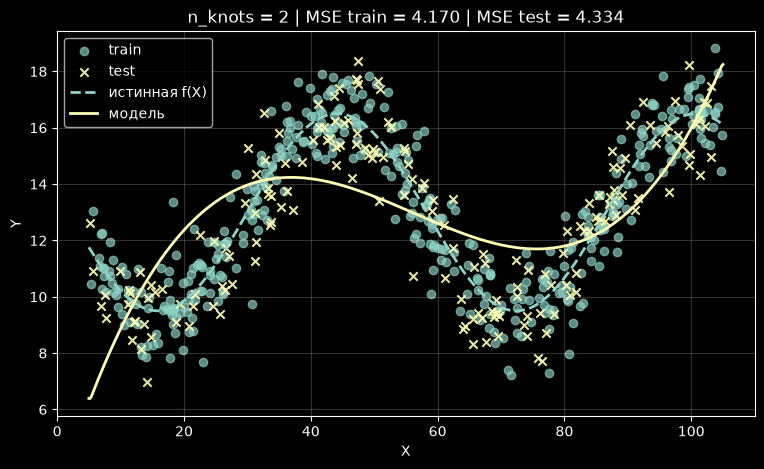

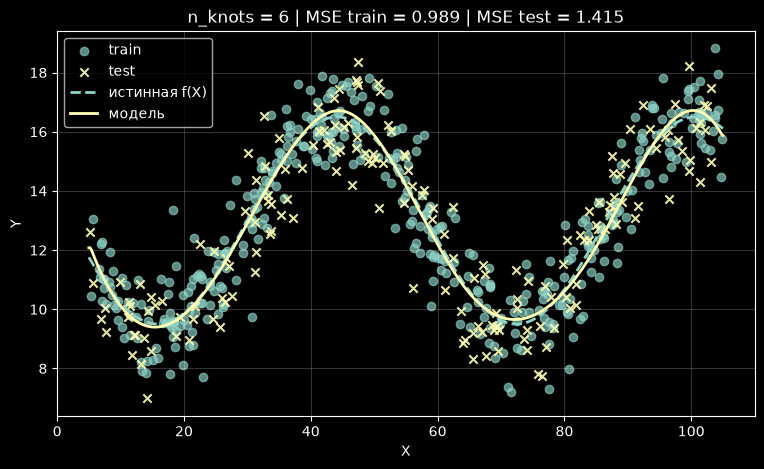

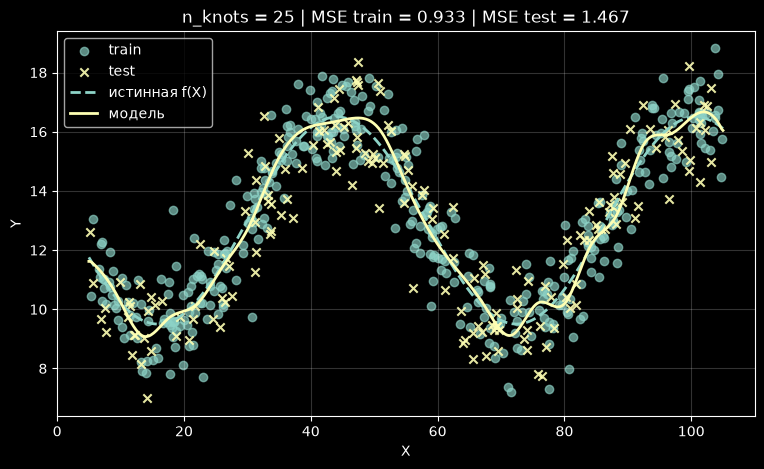

In [8]:
def build_spline_model(n_knots):
    """Создаёт модель: B-сплайновое преобразование + линейная регрессия."""
    return make_pipeline(
        SplineTransformer(
            n_knots=n_knots,
            degree=SPLINE_DEGREE,
            include_bias=False,
            knots="uniform"
        ),
        LinearRegression()
    )


def plot_model(n_knots):
    model = build_spline_model(n_knots)
    model.fit(X_train, y_train)

    y_grid_pred = model.predict(x_grid.reshape(-1, 1))

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mse_manual(y_train, train_pred)
    test_mse = mse_manual(y_test, test_pred)

    plt.figure(figsize=(9, 5))

    plt.scatter(X_train[:, 0], y_train, marker="o", alpha=0.65, label="train")
    plt.scatter(X_test[:, 0], y_test, marker="x", alpha=0.9, label="test")
    plt.plot(x_grid, y_grid_true, linestyle="--", linewidth=2, label="истинная f(X)")
    plt.plot(x_grid, y_grid_pred, linewidth=2, label="модель")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(
        f"n_knots = {n_knots} | "
        f"MSE train = {train_mse:.3f} | "
        f"MSE test = {test_mse:.3f}"
    )
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


for n_knots in [2, 6, 25]:
    plot_model(n_knots)


Теперь последовательно обучим модели с разным количеством узлов:

$$
n\_knots = 2, 3, \ldots, 25.
$$

Для каждой модели посчитаем:

- `MSE_train`;
- `MSE_test`.

In [9]:
results = []

for n_knots in range(MIN_KNOTS, MAX_KNOTS + 1):

    model = build_spline_model(n_knots)
    model.fit(X_train, y_train)

    y_hat_train = model.predict(X_train)
    y_hat_test = model.predict(X_test)

    results.append({
        "n_knots": n_knots,
        "MSE_train": mse_manual(y_train, y_hat_train),
        "MSE_test": mse_manual(y_test, y_hat_test)
    })

results = pd.DataFrame(results)

results

,n_knots,MSE_train,MSE_test
0,2,4.170281,4.334042
1,3,3.410311,3.850154
2,4,1.101809,1.585190
3,5,1.179463,1.684575
4,6,0.989368,1.414546
5,7,0.987306,1.378221
6,8,0.980996,1.365053
7,9,0.981813,1.362478
8,10,0.976456,1.367071
9,11,0.977729,1.365259


In [10]:
# Найдём модель с минимальной ошибкой на тестовой выборке

best_row = results.loc[results["MSE_test"].idxmin()]

print("Лучшее значение n_knots по тестовой выборке:")
print(f"n_knots  = {int(best_row['n_knots'])}")
print(f"MSE_train = {best_row['MSE_train']:.4f}")
print(f"MSE_test  = {best_row['MSE_test']:.4f}")

Лучшее значение n_knots по тестовой выборке:
n_knots  = 9
MSE_train = 0.9818
MSE_test  = 1.3625


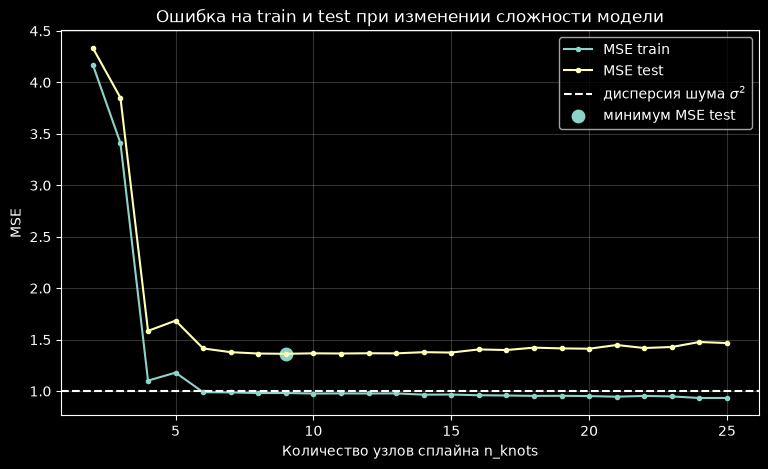

In [11]:
# График зависимости MSE от сложности модели

plt.figure(figsize=(9, 5))

plt.plot(
    results["n_knots"],
    results["MSE_train"],
    marker="o",
    markersize=3,
    label="MSE train"
)

plt.plot(
    results["n_knots"],
    results["MSE_test"],
    marker="o",
    markersize=3,
    label="MSE test"
)

plt.axhline(
    SIGMA ** 2,
    linestyle="--",
    label=r"дисперсия шума $\sigma^2$"
)

plt.scatter(
    best_row["n_knots"],
    best_row["MSE_test"],
    s=80,
    label="минимум MSE test"
)

plt.xlabel("Количество узлов сплайна n_knots")
plt.ylabel("MSE")
plt.title("Ошибка на train и test при изменении сложности модели")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Пояснение выбора наилучшего количества степеней свободы

В моём эксперименте (seed = 1):
- `MSE_train` в оптимуме = 0.9818;
- `MSE_test`  в оптимуме = 1.3625.

### Почему не меньше узлов (underfitting)

При `n_knots < {best}` модель слишком простая:
- df ≈ {best+1} и меньше;
- она не может воспроизвести изгибы истинной функции
  $f(X) = 13 + 3.5\sin\left(\frac{x-30}{9}\right)$;
- `MSE_train` и `MSE_test` обе высокие
  (при `n_knots = 2`: train = 4.170281, test = 4.334042).

Это **underfitting** — большое смещение (bias).

### Почему не больше узлов (overfitting)

При `n_knots > {best}` модель слишком гибкая:
- df ≈ {best+3} и больше;
- она начинает описывать **случайный шум**, а не закономерность;
- `MSE_train` продолжает падать (при `n_knots = 25`: 0.933349),
  а `MSE_test` **растёт** (при `n_knots = 25`: 1.466913);
- разрыв `MSE_test − MSE_train` увеличивается.

Это **overfitting** — большая дисперсия (variance).

### Итог

Оптимальное число степеней свободы — **df ≈ {best+2}**
(что соответствует `n_knots = 9`). Оно даёт **минимальную
ошибку на тестовой выборке**, потому что в этой точке:
- модель уже достаточно гибкая, чтобы описать нелинейную f(X);
- но ещё не настолько гибкая, чтобы подстроиться под шум σ = 1.0.

Минимально возможная `MSE_test` ограничена снизу **дисперсией шума
σ² = 1.0** — идеальная модель не может дать ошибку меньше этого
уровня.

------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Задача 2. Влияние объёма выборки
В варианте 1 исследуется изменение объёма выборки:
$n_{all} = 600,\; 550,\; 500$.
Остальные параметры (`train_percent`, `sigma`) не меняются.

Сделаем универсальную функцию, чтобы такие эксперименты выполнялись одной командой.

In [20]:
def run_experiment(
    n_all=600,
    train_percent=0.70,
    sigma=1.0,
    random_state=1,
    min_knots=2,
    max_knots=25
):
    """Генерирует данные и считает train/test MSE для моделей разной сложности."""

    rng = np.random.default_rng(random_state)

    x_exp = rng.uniform(X_MIN, X_MAX, n_all)
    y_exp = true_function(x_exp) + rng.normal(0, sigma, n_all)

    X_exp = x_exp.reshape(-1, 1)

    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_exp,
        y_exp,
        train_size=train_percent,
        random_state=random_state
    )

    rows = []

    for n_knots in range(min_knots, max_knots + 1):

        model = build_spline_model(n_knots)
        model.fit(X_train_exp, y_train_exp)

        train_pred = model.predict(X_train_exp)
        test_pred = model.predict(X_test_exp)

        rows.append({
            "n_knots": n_knots,
            "MSE_train": mse_manual(y_train_exp, train_pred),
            "MSE_test": mse_manual(y_test_exp, test_pred)
        })

    return pd.DataFrame(rows)


def summarize_experiment(result_table):
    best = result_table.loc[result_table["MSE_test"].idxmin()]

    return {
        "best_n_knots": int(best["n_knots"]),
        "best_MSE_train": best["MSE_train"],
        "best_MSE_test": best["MSE_test"]
    }

Для примера будем менять объем выборки.

Проверим три значения:
$$
n_{all} = 600,\; 550,\; 500.
$$

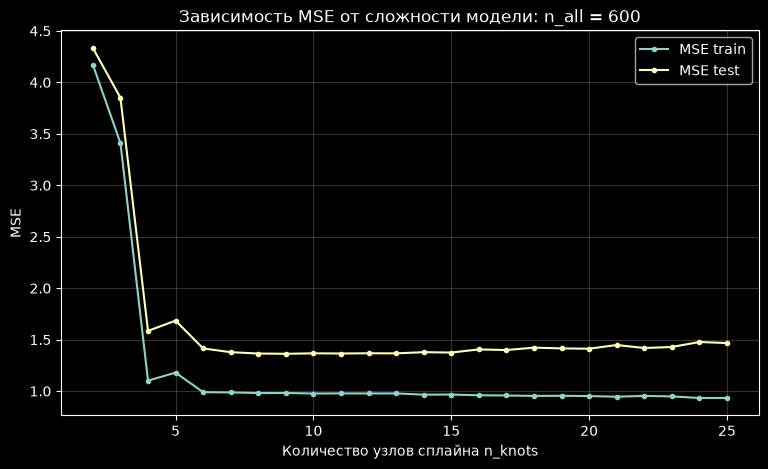

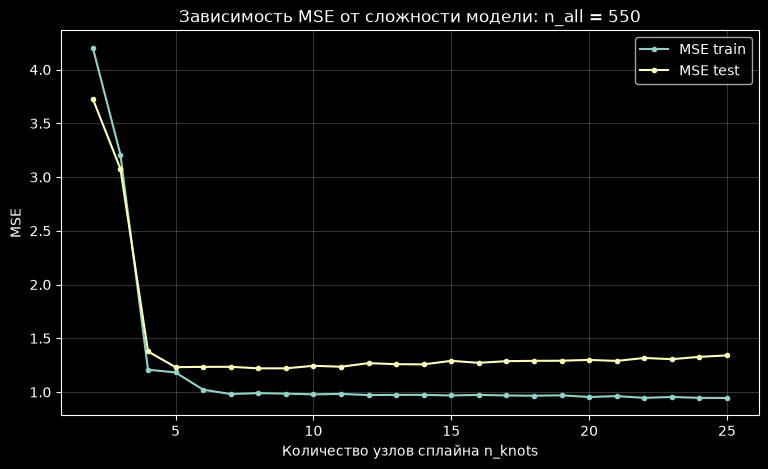

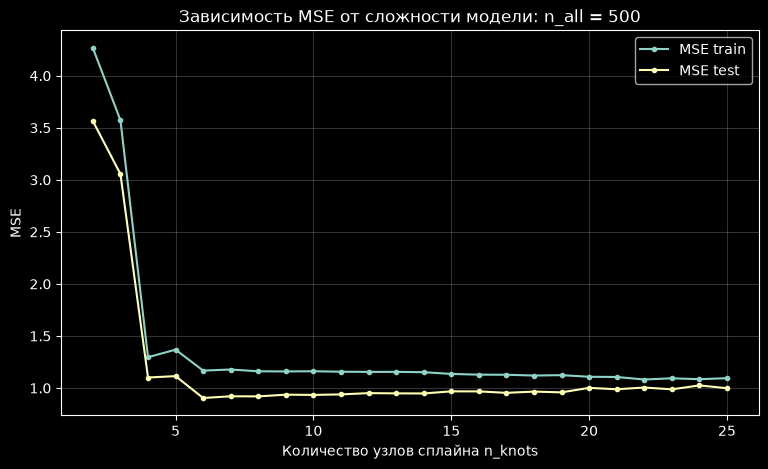

,n_all,best_n_knots,best_MSE_train,best_MSE_test
0,600,9,0.981813,1.362478
1,550,9,0.984745,1.220147
2,500,6,1.167351,0.904291


In [21]:
n_all_values = [600, 550, 500]

summary_rows = []

for n_all in n_all_values:

    experiment = run_experiment(
        n_all=n_all,
        train_percent=TRAIN_PERCENT,
        sigma=SIGMA,
        random_state=RANDOM_STATE
    )

    summary = summarize_experiment(experiment)
    summary["n_all"] = n_all
    summary_rows.append(summary)

    plt.figure(figsize=(9, 5))

    plt.plot(
        experiment["n_knots"],
        experiment["MSE_train"],
        marker="o",
        markersize=3,
        label="MSE train"
    )

    plt.plot(
        experiment["n_knots"],
        experiment["MSE_test"],
        marker="o",
        markersize=3,
        label="MSE test"
    )

    plt.xlabel("Количество узлов сплайна n_knots")
    plt.ylabel("MSE")
    plt.title(f"Зависимость MSE от сложности модели: n_all = {n_all}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

summary_n_all = pd.DataFrame(summary_rows)[
    ["n_all", "best_n_knots", "best_MSE_train", "best_MSE_test"]
]

summary_n_all

### Что видно

Формально MSE_test снизилась с 1.36 до 0.90.
Но это **не значит**, что меньше данных — лучше.

### Почему так получилось

1. Тестовая выборка маленькая (150–180 точек),
   поэтому MSE_test «скачет» от прогона к прогону.

2. При n_all = 500 и seed = 1 тестовые точки
   случайно оказались «удачными» — шума в них
   меньше обычного. MSE_test = 0.90 даже ниже
   уровня шума σ² = 1.0 — это явный признак
   случайности, а не закономерности.

3. Оптимум сместился с 9 узлов на 6 — модель
   стала проще, у неё меньше разброс.

### Вывод

На одном прогоне MSE_test не показывает
ожидаемого роста при уменьшении выборки.
Это объясняется малой тестовой выборкой
и случайной удачей с данными.

------------------------------------------------------------------------------------------------------------------------------------------------------------

## Дополнительный эксперимент: влияние train_percent

Формально по варианту 1 в задаче 2 исследуется n_all.
Дополнительно я решила проверить, как влияет доля обучающей выборки.

### Параметры
- n_all = 600 (фиксировано)
- train_percent = 0.9, 0.85, 0.8
- seed = 1, sigma = 1.0


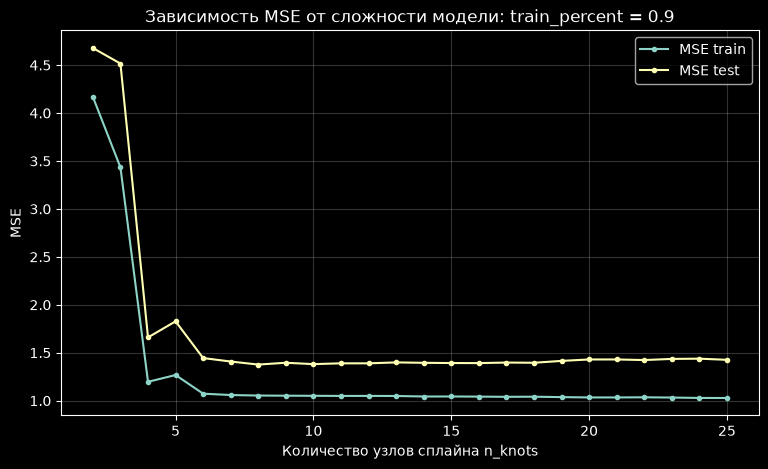

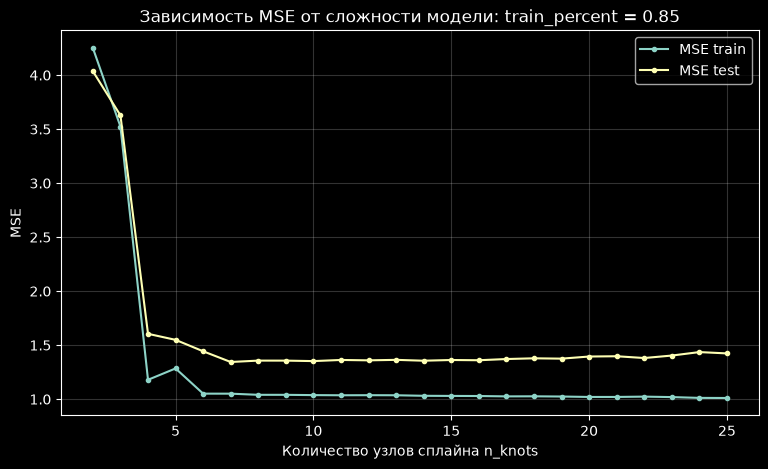

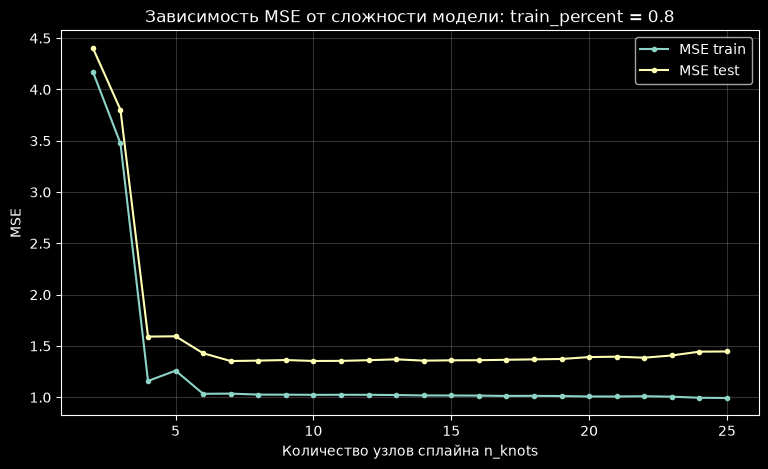

,train_percent,best_n_knots,best_MSE_train,best_MSE_test
0,0.90,8,1.053150,1.376307
1,0.85,7,1.050986,1.344264
2,0.80,7,1.035721,1.353212


In [22]:
train_percent_values = [0.9, 0.85, 0.8]

summary_rows = []

for tp in train_percent_values:

    experiment = run_experiment(
        n_all=N_ALL,
        train_percent=tp,
        sigma=SIGMA,
        random_state=RANDOM_STATE
    )

    summary = summarize_experiment(experiment)
    summary["train_percent"] = tp
    summary_rows.append(summary)

    plt.figure(figsize=(9, 5))

    plt.plot(
        experiment["n_knots"],
        experiment["MSE_train"],
        marker="o",
        markersize=3,
        label="MSE train"
    )

    plt.plot(
        experiment["n_knots"],
        experiment["MSE_test"],
        marker="o",
        markersize=3,
        label="MSE test"
    )

    plt.xlabel("Количество узлов сплайна n_knots")
    plt.ylabel("MSE")
    plt.title(f"Зависимость MSE от сложности модели: train_percent = {tp}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

summary_train_percent = pd.DataFrame(summary_rows)[
    ["train_percent", "best_n_knots", "best_MSE_train", "best_MSE_test"]
]

summary_train_percent

### Что видно

1. **MSE_train почти не меняется.**
   Значения 1.0532 → 1.0510 → 1.0357 мало отличаются.
   Модель учится одинаково хорошо
   при всех трёх значениях train_percent.

2. **MSE_test колеблется**
   1.3763 → 1.3443 → 1.3532. Это не закономерность,
   а случайный разброс.

3. **Оптимум n_knots сместился с 8 на 7.**
   При меньшей обучающей выборке модель выбирает
   чуть более простую конфигурацию.

### Вывод

Явного влияния train_percent на MSE_test
в этом эксперименте **не наблюдается**.
Все три значения дают практически одинаковый
результат (в пределах случайной погрешности).

Причина: при n_all = 600 даже 480 обучающих
точек достаточно, чтобы модель хорошо обучилась.
А тестовая выборка слишком мала, чтобы уловить
разницу между 0.9 и 0.8.

Можно сказать так: **при большом объёме данных
изменение train_percent в диапазоне 0.8–0.9
практически не влияет на качество модели.**